<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/pytorch_paper_replicating_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4399 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 36.38 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [5]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

In [6]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b9a7a376480>,
 ['pizza', 'steak', 'sushi'])

In [8]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


(torch.Size([3, 224, 224]), tensor(2))

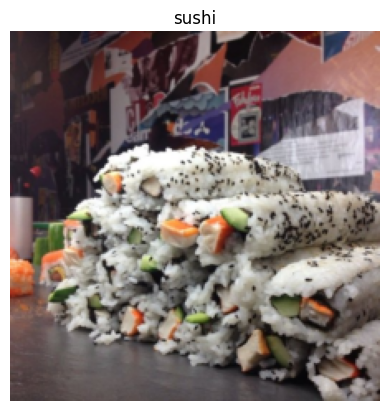

In [9]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

In [10]:
height = 224
width = 224
color_channels = 3
patch_size = 16

num_of_patches = int((height * width) / (patch_size ** 2))

print(f'Number of patches: {num_of_patches}')

Number of patches: 196


In [11]:
input_shape = (height, width, color_channels)
output_shape = (num_of_patches, patch_size ** 2 * color_channels)
print(f'Input shape: {input_shape}')
print(f'Output shape: {output_shape}')

Input shape: (224, 224, 3)
Output shape: (196, 768)


In [12]:
image.shape

torch.Size([3, 224, 224])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

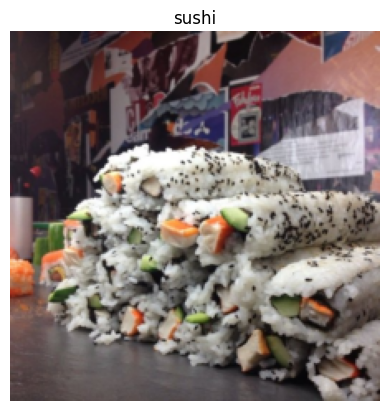

In [13]:
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

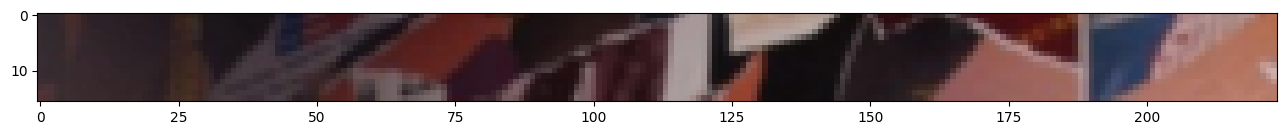

In [14]:
image_permuted = image.permute(1, 2, 0)
patch_size = 16

plt.figure(figsize = (patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])

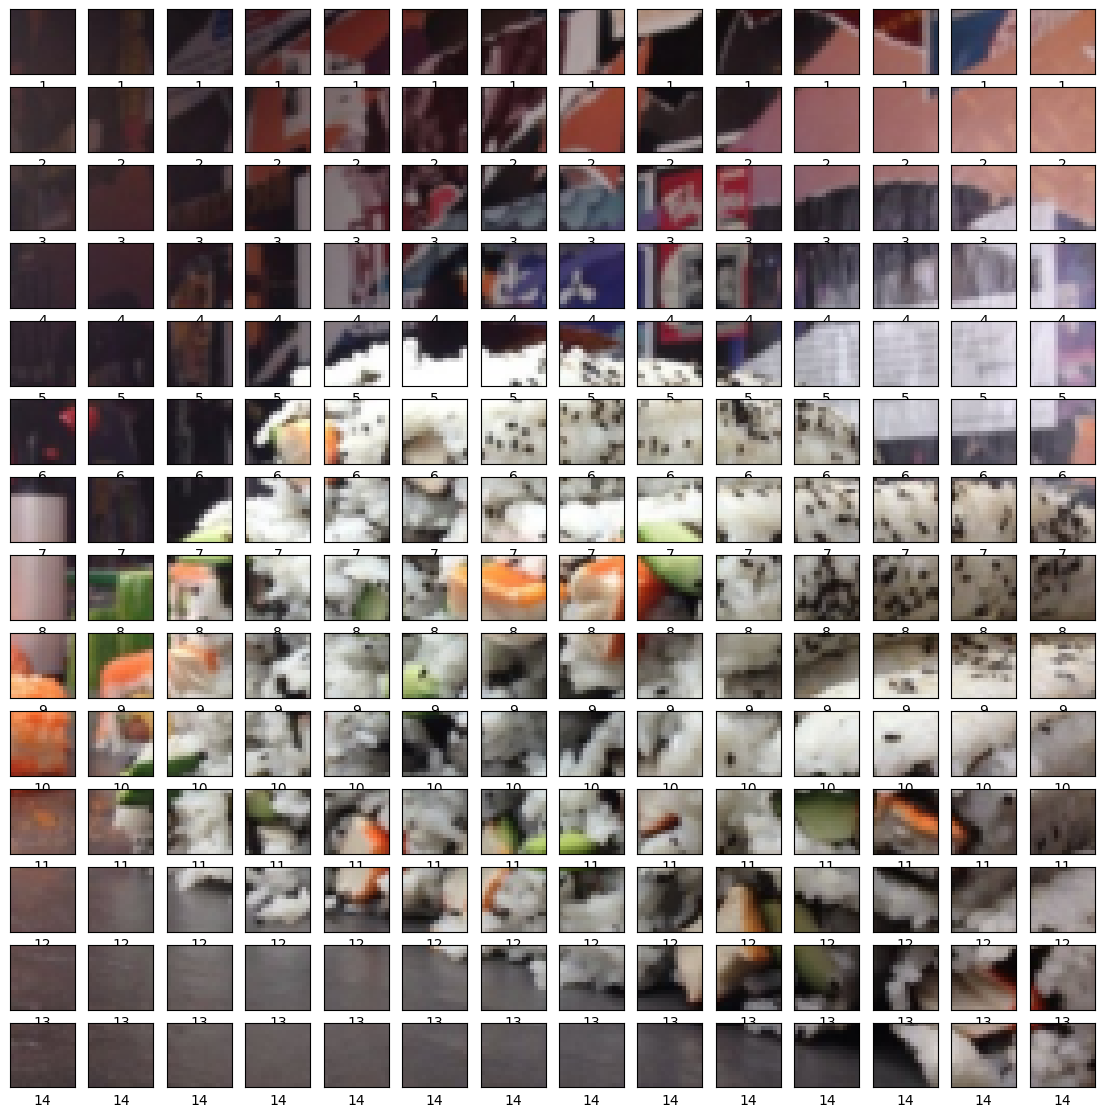

In [15]:
img_size = 224
patch_size = 16

num_of_patches = int(img_size / patch_size)

assert img_size % patch_size == 0, 'Image size must be divisible by patch size'

fig, axes = plt.subplots(nrows = num_of_patches, ncols = num_of_patches, figsize = (num_of_patches, num_of_patches), sharex = True, sharey = True)

for i, patch_i in enumerate(range(0, img_size, patch_size)):
  for j, patch_j in enumerate(range(0, img_size, patch_size)):
    axes[i][j].imshow(image_permuted[patch_i:patch_i + patch_size, patch_j:patch_j + patch_size, :])
    axes[i][j].set_xlabel(i + 1)
    axes[i][j].set_xticks([])
    axes[i][j].set_yticks([])

In [16]:
image.shape

torch.Size([3, 224, 224])

In [17]:
from torch import nn

patch_size = 16

conv2d = nn.Conv2d(in_channels = 3,
                   out_channels = 768,
                   kernel_size = patch_size,
                   stride = patch_size,
                   padding = 0)

In [18]:
image_out_of_conv = conv2d(image.unsqueeze(0))
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

Random Indexes: [63, 719, 269, 319, 128]


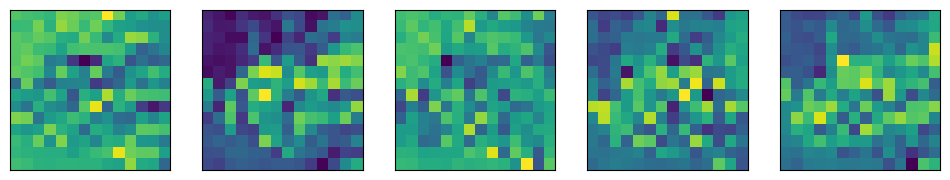

In [19]:
import random
random_indexes = random.sample(range(0, 758), k = 5)
print(f'Random Indexes: {random_indexes}')

fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize = (12, 12))

for i, idx in enumerate(random_indexes):
  image_conv_feature_map = image_out_of_conv[:, idx, :, :]
  axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
  axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [20]:
single_feature_map = image_out_of_conv[:, idx, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[ 0.1548,  0.1077,  0.0909,  0.0925,  0.1652,  0.1935,  0.1072,
            0.3617,  0.1266,  0.0601,  0.1776,  0.2337,  0.2576,  0.4104],
          [ 0.1550,  0.1316,  0.1788,  0.1534,  0.3101,  0.1958,  0.2134,
            0.3208,  0.2096,  0.1441,  0.3090,  0.3124,  0.3758,  0.4097],
          [ 0.1750,  0.1261,  0.1137,  0.1622,  0.4036,  0.2029,  0.1928,
            0.2274,  0.3238,  0.2380,  0.2196,  0.2158,  0.2920,  0.4750],
          [ 0.1582,  0.1445,  0.1408,  0.0916,  0.3202,  0.1868,  0.1593,
            0.2194,  0.2372,  0.2932,  0.1941,  0.3356,  0.2954,  0.6672],
          [ 0.1209,  0.1442,  0.1655,  0.1164,  0.3453,  0.7310,  0.4394,
            0.4387,  0.4764,  0.3808,  0.4551,  0.5492,  0.5090,  0.6383],
          [ 0.1624,  0.1693,  0.1279,  0.0155,  0.3272,  0.5434,  0.5287,
            0.5801,  0.4486,  0.2985,  0.3437,  0.3991,  0.3093,  0.4923],
          [ 0.5132,  0.1692,  0.2352,  0.4624,  0.3776,  0.5384,  0.5282,
            0.6872,  0.5189,  0.

In [21]:
image_out_of_conv.shape, single_feature_map.shape

(torch.Size([1, 768, 14, 14]), torch.Size([1, 14, 14]))

In [22]:
flatten = nn.Flatten(start_dim = 2,end_dim = 3)

In [23]:
image.shape

torch.Size([3, 224, 224])

Original image shape: torch.Size([3, 224, 224])
image_conv_shape: torch.Size([1, 768, 14, 14])
image_flatten_shape: torch.Size([1, 768, 196])


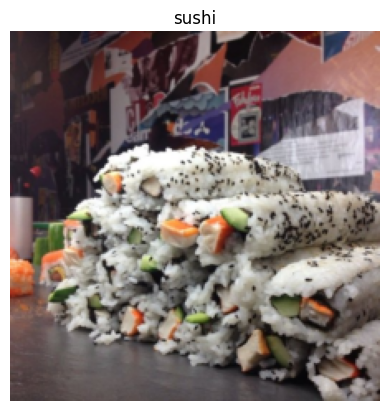

In [24]:
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

image_conv_shape = conv2d(image.unsqueeze(0))
print(f'image_conv_shape: {image_conv_shape.shape}')

image_flatten_shape = flatten(image_conv_shape)
print(f'image_flatten_shape: {image_flatten_shape.shape}')

In [25]:
image_conv_flattened_reshaped = image_flatten_shape.permute(0, 2, 1)
print(f'Embedding sequence shape: {image_conv_flattened_reshaped.shape}')

Embedding sequence shape: torch.Size([1, 196, 768])


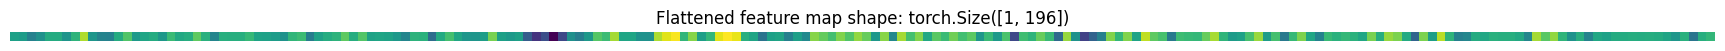

In [26]:
single_flattened_feature_map = image_conv_flattened_reshaped[:, :, 0]

plt.figure(figsize = (22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f'Flattened feature map shape: {single_flattened_feature_map.shape}')
plt.axis(False);

In [27]:
single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[ 0.0808,  0.0694, -0.0197,  0.0342,  0.1178,  0.1180,  0.0432,  0.1456,
           0.3228,  0.0472, -0.0115, -0.0184,  0.1167,  0.2052,  0.0591,  0.0975,
           0.1184,  0.0515,  0.1693,  0.1089,  0.1230,  0.2263,  0.1321, -0.0053,
           0.1300,  0.1261,  0.1256,  0.1594,  0.0906,  0.0842,  0.0684,  0.0368,
           0.1513,  0.1732, -0.0309,  0.0855,  0.1200,  0.1407,  0.2227,  0.1239,
           0.2094,  0.0885,  0.0961,  0.0882,  0.0543, -0.0062,  0.1407,  0.1370,
          -0.0828,  0.1141,  0.1883,  0.0980,  0.0478,  0.0459,  0.0717,  0.2595,
           0.0828,  0.0583,  0.0806, -0.1312, -0.2431, -0.1717, -0.3584, -0.1919,
           0.0306, -0.0262,  0.0539,  0.2099,  0.1713,  0.3096,  0.0963,  0.0969,
           0.0363,  0.0345,  0.3195,  0.3802,  0.4083,  0.1522,  0.2734,  0.0739,
           0.1541,  0.3832,  0.4153,  0.3885,  0.1286,  0.0936, -0.0645,  0.0828,
           0.0945, -0.0216,  0.0786,  0.0061,  0.2751,  0.2335,  0.1851,  0.2679,
           0.204

In [28]:
class PatchEmbedding(nn.Module):
  def __init__(self,
               in_channels: int = 3,
               patch_size: int = 16,
               embedding_dim: int = 768):
    super().__init__()
    self.patcher = nn.Conv2d(in_channels = in_channels,
                             out_channels = embedding_dim,
                             kernel_size = patch_size,
                             stride = patch_size,
                             padding = 0)

    self.flatten = nn.Flatten(start_dim = 2, end_dim = 3)

  def forward(self, x):
    image_resolution = x.shape[-1]
    assert image_resolution % patch_size == 0, f'Input image size must be divisible by patch size, image_shape: {image_resolution}, patch_size: {patch_size}'
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)
    return x_flattened.permute(0, 2, 1)

In [29]:
set_seeds()

patchify = PatchEmbedding(in_channels = 3,
                          patch_size = 16,
                          embedding_dim = 768)

print(f'Input image shape: {image.unsqueeze(0).shape}')
patch_embedded_image = patchify(image.unsqueeze(0))
print(f'Output patch embedding shape: {patch_embedded_image.shape}')

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768])


In [30]:
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250)

summary(PatchEmbedding(),
        input_size = random_input_image,
        col_names = ['input_size', 'output_size', 'num_params', 'trainable'],
        col_width = 20,
        row_settings = ['var_names'])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [31]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [32]:
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), requires_grad = True)

print(class_token[:, :, :10])

print(f'Class Token Shape: {class_token.shape}')

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class Token Shape: torch.Size([1, 1, 768])


In [33]:
patch_embedded_with_class_embedding = torch.cat((class_token, patch_embedded_image), dim = 1)
print(patch_embedded_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_with_class_embedding.shape}")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.1923,  0.0102, -0.0742,  ...,  0.1512, -0.0789,  0.0827],
         [-0.1951, -0.0160, -0.0600,  ...,  0.1413, -0.0804,  0.0414],
         ...,
         [-0.5913,  0.2441,  0.0677,  ...,  0.3303, -0.2150, -0.0175],
         [-0.2717,  0.0294, -0.3839,  ...,  0.2838, -0.1246,  0.4697],
         [-0.5201,  0.1673, -0.1228,  ...,  0.2707, -0.1276,  0.1437]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768])


In [34]:
num_of_patches = int((224 * 224) / patch_size ** 2)

embedding_dimension = patch_embedded_with_class_embedding.shape[2]

position_embedding = nn.Parameter(torch.ones(1, num_of_patches + 1, embedding_dimension), requires_grad = True)

print(position_embedding[:, :10, :10])
print(f'Position Embedding Shape: {position_embedding.shape}')

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position Embedding Shape: torch.Size([1, 197, 768])


In [35]:
patch_and_position_embedding = patch_embedded_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f'Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape}')

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.8077, 1.0102, 0.9258,  ..., 1.1512, 0.9211, 1.0827],
         [0.8049, 0.9840, 0.9400,  ..., 1.1413, 0.9196, 1.0414],
         ...,
         [0.4087, 1.2441, 1.0677,  ..., 1.3303, 0.7850, 0.9825],
         [0.7283, 1.0294, 0.6161,  ..., 1.2838, 0.8754, 1.4697],
         [0.4799, 1.1673, 0.8772,  ..., 1.2707, 0.8724, 1.1437]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positional embeddings added shape: torch.Size([1, 197, 768])


In [36]:
set_seeds()

patch_size = 16

print(f'Image tensor shape: {image.shape}')
height, width = image.shape[1], image.shape[2]

x = image.unsqueeze(0)
print(f'Image shape with batch dimension: {x.shape}')

patch_embedding_layer = PatchEmbedding(in_channels = 3,
                                       patch_size = patch_size,
                                       embedding_dim = 768)

patch_embedding = patch_embedding_layer(x)
print(f'Patch Embedding shape: {patch_embedding.shape}')

batch_size = patch_embedding.shape[0]
embedding_dmension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dmension), requires_grad= True)
print(f'Class Token embedding shape: {class_token.shape}')

patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim = 1)
print(f'Patch Embedding with class token shape: {patch_embedding_class_token.shape}')

number_of_patches = int((height * width) / patch_size ** 2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches + 1, 768), requires_grad = True)

patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f'Patch and position embedding shape: {patch_and_position_embedding.shape}')

Image tensor shape: torch.Size([3, 224, 224])
Image shape with batch dimension: torch.Size([1, 3, 224, 224])
Patch Embedding shape: torch.Size([1, 196, 768])
Class Token embedding shape: torch.Size([1, 1, 768])
Patch Embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


In [37]:
class MultiheadSelfAttentionBlock(nn.Module):
  def __init__(self,
               embedding_dim: int = 768,
               num_heads: int = 12,
               attn_dropout: float = 0):
    super().__init__()
    self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)
    self.multihead_attn = nn.MultiheadAttention(embed_dim = embedding_dim,
                                                num_heads = num_heads,
                                                dropout = attn_dropout,
                                                batch_first = True)
  def forward(self, x):
    x = self.layer_norm(x)
    attn_output, _ = self.multihead_attn(query = x,
                                         key = x,
                                         value = x,
                                         need_weights = False)
    return attn_output

In [38]:
multihead_self_attention_block = MultiheadSelfAttentionBlock(embedding_dim = 768,
                                                             num_heads = 12)
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)

print(f'Input shape of MSA block: {patch_and_position_embedding.shape}')
print(f'Output shape of MSA block: {patched_image_through_msa_block.shape}')

Input shape of MSA block: torch.Size([1, 197, 768])
Output shape of MSA block: torch.Size([1, 197, 768])


In [39]:
class MLPBlock(nn.Module):
  def __init__(self,
               embedding_dim: int = 768,
               mlp_size: int = 3072,
               dropout: float = 0.1):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)

    self.mlp = nn.Sequential(
        nn.Linear(in_features = embedding_dim,
                  out_features = mlp_size),
        nn.GELU(),
        nn.Dropout(p = dropout),
        nn.Linear(in_features = mlp_size,
                  out_features = embedding_dim),
        nn.Dropout(p = dropout)
    )

  def forward(self, x):
    x = self.layer_norm(x)
    x = self.mlp(x)
    return x

In [40]:
mlp_block = MLPBlock(embedding_dim = 768,
                     mlp_size = 3072,
                     dropout = 0.1)

patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f'Input shape of MLP Block: {patched_image_through_msa_block.shape}')
print(f'Output shape of MLP Block: {patched_image_through_mlp_block.shape}')

Input shape of MLP Block: torch.Size([1, 197, 768])
Output shape of MLP Block: torch.Size([1, 197, 768])


In [41]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               embedding_dim: int = 768,
               num_heads: int = 12,
               attn_dropout: float = 0,
               mlp_size: int = 3072,
               mlp_dropout: float = 0.1):
    super().__init__()
    self.msa_block = MultiheadSelfAttentionBlock(embedding_dim = embedding_dim,
                                                 num_heads = num_heads,
                                                 attn_dropout = attn_dropout)
    self.mlp_block = MLPBlock(embedding_dim = embedding_dim,
                              mlp_size = mlp_size,
                              dropout = mlp_dropout)

  def forward(self, x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x
    return x

In [42]:
transformer_encoder_block = TransformerEncoderBlock()

summary(model = transformer_encoder_block,
        input_size = (1, 197, 768),
        col_names = ['input_size', 'output_size', 'num_params', 'trainable'],
        col_width = 20,
        row_settings = ['var_names'])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiheadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [43]:
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model = 768,
                                                             nhead = 12,
                                                             dim_feedforward = 3072,
                                                             dropout = 0.1,
                                                             activation = 'gelu',
                                                             batch_first = True,
                                                             norm_first = True)

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [44]:
summary(model = torch_transformer_encoder_layer,
        input_size = (1, 197, 768),
        col_names = ['input_size', 'output_size', 'num_params', 'trainable'],
        col_width = 20,
        row_settings = ['var_names'])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

In [45]:
class ViT(nn.Module):
  def __init__(self,
               img_size: int = 224,
               in_channels: int = 3,
               patch_size: int = 16,
               num_transformer_layers: int = 12,
               embedding_dim: int = 768,
               mlp_size: int = 3072,
               num_heads: int = 12,
               attn_dropout: float = 0,
               mlp_dropout: float = 0.1,
               embedding_dropout:float = 0.1,
               num_classes: int = 1000):
    super().__init__()
    assert img_size % patch_size == 0, f'Image size must be divisible by patch_size, image size: {img_size}, patch_size: {patch_size}.'
    self.num_patches = (img_size * img_size) // patch_size ** 2
    self.patch_embedding = PatchEmbedding(in_channels = in_channels,
                                          patch_size = patch_size,
                                          embedding_dim = embedding_dim)
    self.class_embedding = nn.Parameter(data = torch.randn(1, 1, embedding_dim), requires_grad = True)
    self.position_embedding = nn.Parameter(data = torch.randn(1, self.num_patches + 1, embedding_dim), requires_grad = True)
    self.embedding_dropout = nn.Dropout(p = embedding_dropout)
    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim = embedding_dim,
                                                                      num_heads = num_heads,
                                                                      attn_dropout = attn_dropout,
                                                                      mlp_size = mlp_size,
                                                                      mlp_dropout = mlp_dropout) for _ in range(num_transformer_layers)])

    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape = embedding_dim),
        nn.Linear(in_features = embedding_dim,
                  out_features = num_classes)
    )

  def forward(self, x):
    batch_size = x.shape[0]
    class_token = self.class_embedding.expand(batch_size, -1, -1)
    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim = 1)
    x = x + self.position_embedding
    x = self.embedding_dropout(x)
    x = self.transformer_encoder(x)
    x = self.classifier(x[:, 0])
    return x

In [46]:
batch_size = 32
class_token_embedding_single = nn.Parameter(torch.randn(1, 1, 768))
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1)

print(f'Shape of class token embedding single: {class_token_embedding_single.shape}')
print(f'Shape of class token ebedding expanded: {class_token_embedding_expanded.shape}')

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token ebedding expanded: torch.Size([32, 1, 768])


In [47]:
set_seeds

random_image_tensor = torch.randn((1, 3, 224, 224))
vit = ViT(num_classes = len(class_names))
vit(random_image_tensor)

tensor([[-0.2181,  0.2005,  1.0755]], grad_fn=<AddmmBackward0>)

In [48]:
from torchinfo import summary

# Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [32, 3, 224, 224]    [32, 3]              152,064              True
├─PatchEmbedding (patch_embedding)                           [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (patcher)                                      [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                                     [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                                [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (transformer_encoder)                           [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)                           [32, 197, 768]       [32, 197, 768]

In [49]:
# from going_modular.going_modular import engine

# optimizer = torch.optim.Adam(params = vit.parameters(),
#                              lr = 3e-3,
#                              betas = (0.9, 0.999),
#                              weight_decay = 0.3)

# loss_fn = torch.nn.CrossEntropyLoss()

# set_seeds()

# results = engine.train(model = vit,
#                        train_dataloader = train_dataloader,
#                        test_dataloader = test_dataloader,
#                        optimizer = optimizer,
#                        loss_fn = loss_fn,
#                        epochs = 10,
#                        device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
# from helper_functions import plot_loss_curves

# plot_loss_curves(results)

In [50]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


In [51]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [53]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
pretrained_vit = torchvision.models.vit_b_16(weights = pretrained_vit_weights).to(device)

for parameter in pretrained_vit.parameters():
  parameter.requires_grad = False

set_seeds()

pretrained_vit.heads = nn.Linear(in_features = 768, out_features = len(class_names)).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 51.7MB/s]


In [54]:
summary(model=pretrained_vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 3]              768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

In [55]:
from helper_functions import download_data

image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")

image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [56]:
train_dir = image_path / 'train'
test_dir = image_path / 'test'

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [58]:
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [59]:
train_dataloader_pretrained, test_dataloader_pretrained, class_names = data_setup.create_dataloaders(train_dir = train_dir,
                                                                                                     test_dir = test_dir,
                                                                                                     transform = pretrained_vit_transforms,
                                                                                                     batch_size = 32)

In [61]:
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(params = pretrained_vit.parameters(),
                             lr = 1e-3)

loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()

pretrained_vit_results = engine.train(model = pretrained_vit,
                                      train_dataloader = train_dataloader_pretrained,
                                      test_dataloader = test_dataloader_pretrained,
                                      optimizer = optimizer,
                                      loss_fn = loss_fn,
                                      epochs = 10,
                                      device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
from helper_functions import plot_loss_curves

plot_loss_curves(pretrained_vit_results)

In [62]:
from going_modular.going_modular import utils

utils.save_model(model = pretrained_vit,
                 target_dir = 'models',
                 model_name = 'pretrained_vit_feature_extractor_pizza_steak_sushi.pth')

[INFO] Saving model to: models/pretrained_vit_feature_extractor_pizza_steak_sushi.pth


In [63]:
from pathlib import Path

pretrained_vit_model_size = Path('models/pretrained_vit_feature_extractor_pizza_steak_sushi.pth').stat().st_size // (1024*1024)
print(f'Model size: {pretrained_vit_model_size} MB')

Model size: 327 MB


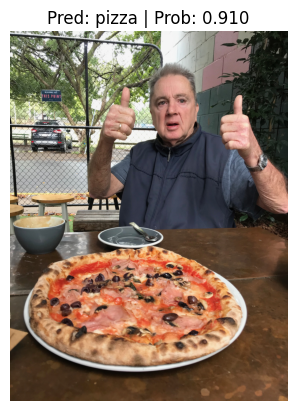

In [64]:
import requests

# Import function to make predictions on images and plot them
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = image_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)